In [1]:
# %matplotlib ipympl

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from pyqualw2.config import Config
from pyqualw2.config.inputs import FlowInput
from pyqualw2.model_runner import ModelRunner
from pyqualw2.outputs import QWO, QWOLayers, MultiRunResult

In [2]:
data_path = Path("./model/")
inputs = data_path / "inputs"
historic = data_path / "historic_data"
output_dir_ExB = Path("analysis_runs/2026_Exhibit_B_Flow")
output_dir_RA = Path("analysis_runs/2026_RA_Flow")
output_dir_RipCon = Path("analysis_runs/2026_Riparian_Contract_Flow")

temperature_2022 = historic / "temp_data" / "SJA_2022_temp.csv"

config_ExB_flow = Config.from_files(
    name="2022_Observed_Flow",
    con=data_path / "w2_con.csv",
    bathymetry=inputs / "mbth_wb1.csv",
    profile=inputs / "mvpr1.npt",
    met_data=historic / "met_data" / "2022_CEQUAL_met_inputs.csv",
    shade=inputs / "mshade.npt",
    temperature_tributaries=[inputs / "mtdt_br1.npt"],
    # See note about why this is 4 separate values, while the other branch-dependent arguments are not.
    temp_data=[temperature_2022, temperature_2022, temperature_2022, temperature_2022],
    flow_data=historic / "flow_data" / "2026_Ex_B_Flow_2022.csv",
    wind_sheltering=inputs / "mwsc.npt",
    flow_data_date_col="Date",
    flow_data_inflow_cols=[["Date", "M_IN"]],
    flow_data_outflow_cols=[["Date", "SPL_OUT", "FKC_OUT", "MC_OUT", "SJR_OUT"]],
    flow_data_evaporation_cols=[["Date", "MIL_EVAP"]],
)



config_RA_flow = Config.from_files(
    name="2026_RA_rec_flow",
    con=data_path / "w2_con.csv",
    bathymetry=inputs / "mbth_wb1.csv",
    profile=inputs / "mvpr1.npt",
    met_data=historic / "met_data" / "2022_CEQUAL_met_inputs.csv",
    shade=inputs / "mshade.npt",
    temperature_tributaries=[inputs / "mtdt_br1.npt"],
    # See note about why this is 4 separate values, while the other branch-dependent arguments are not.
    temp_data=[temperature_2022, temperature_2022, temperature_2022, temperature_2022],
    flow_data=historic / "flow_data" / "2026_RA_Rec_Flow_2022.csv",
    wind_sheltering=inputs / "mwsc.npt",
    flow_data_date_col="Date",
    flow_data_inflow_cols=[["Date", "M_IN"]],
    flow_data_outflow_cols=[["Date", "SPL_OUT", "FKC_OUT", "MC_OUT", "SJR_OUT"]],
    flow_data_evaporation_cols=[["Date", "MIL_EVAP"]],
)

config_RipCon_flow = Config.from_files(
    name="2026_RA_rec_flow",
    con=data_path / "w2_con.csv",
    bathymetry=inputs / "mbth_wb1.csv",
    profile=inputs / "mvpr1.npt",
    met_data=historic / "met_data" / "2022_CEQUAL_met_inputs.csv",
    shade=inputs / "mshade.npt",
    temperature_tributaries=[inputs / "mtdt_br1.npt"],
    # See note about why this is 4 separate values, while the other branch-dependent arguments are not.
    temp_data=[temperature_2022, temperature_2022, temperature_2022, temperature_2022],
    flow_data=historic / "flow_data" / "2026_Rip_Con_Flow_2022.csv",
    wind_sheltering=inputs / "mwsc.npt",
    flow_data_date_col="Date",
    flow_data_inflow_cols=[["Date", "M_IN"]],
    flow_data_outflow_cols=[["Date", "SPL_OUT", "FKC_OUT", "MC_OUT", "SJR_OUT"]],
    flow_data_evaporation_cols=[["Date", "MIL_EVAP"]],
)

In [3]:
config_ExB_flow.con.timedata = ( 37016.0416,37253.91584,1921)
config_ExB_flow.bathymetry.segment_data["ELWS [m]"] = 166.87
config_RA_flow.con.timedata = ( 37016.0416,37253.91584,1921)
config_RA_flow.bathymetry.segment_data["ELWS [m]"] = 166.87
config_RipCon_flow.con.timedata = ( 37016.0416,37253.91584,1921)
config_RipCon_flow.bathymetry.segment_data["ELWS [m]"] = 166.87

In [4]:
# Due to misconfiguration in w2_con.csv for this test data, we need to fiddle
# the branch data to get cequalw2 to run. See
# https://github.com/steelhead-dev/pyqualw2/issues/69 for more information.
# Set all the flow to 0 for branches 2, 3, and 4. Then add three copies of this
# dummy data to serve as those dummy branches
dummy_flow_data = config_ExB_flow.branch_inflow[0].data.copy()
dummy_flow_data.iloc[:, 1] = 0
config_ExB_flow.branch_inflow.extend(
    [
        FlowInput(data=dummy_flow_data.copy()),
        FlowInput(data=dummy_flow_data.copy()),
        FlowInput(data=dummy_flow_data.copy()),
    ]
)
dummy_flow_data = config_RA_flow.branch_inflow[0].data.copy()
dummy_flow_data.iloc[:, 1] = 0
config_RA_flow.branch_inflow.extend(
    [
        FlowInput(data=dummy_flow_data.copy()),
        FlowInput(data=dummy_flow_data.copy()),
        FlowInput(data=dummy_flow_data.copy()),
    ]
)
dummy_flow_data = config_RipCon_flow.branch_inflow[0].data.copy()
dummy_flow_data.iloc[:, 1] = 0
config_RipCon_flow.branch_inflow.extend(
    [
        FlowInput(data=dummy_flow_data.copy()),
        FlowInput(data=dummy_flow_data.copy()),
        FlowInput(data=dummy_flow_data.copy()),
    ]
)

In [5]:
met_para_list = [historic / "met_data" /"2022_CEQUAL_met_inputs.csv",
historic / "met_data" /"2023_CEQUAL_met_inputs.csv",
historic / "met_data" /"2024_CEQUAL_met_inputs.csv",
historic / "met_data" /"2021_CEQUAL_met_inputs.csv",
historic / "met_data" /"2020_CEQUAL_met_inputs.csv",
historic / "met_data" /"2019_CEQUAL_met_inputs.csv",
historic / "met_data" /"2018_CEQUAL_met_inputs.csv",
historic / "met_data" /"2017_CEQUAL_met_inputs.csv",
historic / "met_data" /"2016_CEQUAL_met_inputs.csv",
historic / "met_data" /"2015_CEQUAL_met_inputs.csv",
historic / "met_data" /"2014_CEQUAL_met_inputs.csv",]

configs_ExB = config_ExB_flow.parameterize({"met_data":met_para_list})
configs_RA = config_RA_flow.parameterize({"met_data":met_para_list})
configs_RipCon = config_RipCon_flow.parameterize({"met_data":met_para_list})

In [6]:
# ModelRunner(configs_ExB, output_dir=output_dir_ExB).run()
# ModelRunner(configs_RA, output_dir=output_dir_RA).run()
# ModelRunner(configs_RipCon, output_dir=output_dir_RipCon).run()

In [7]:
mrr_RA = MultiRunResult("./analysis_runs/2026_RA_Flow")
mrr_ExB = MultiRunResult("./analysis_runs/2026_Exhibit_B_Flow")
mrr_RipCon = MultiRunResult("./analysis_runs/2026_Riparian_Contract_Flow")

## Comparison Plots

Comparing temperature data for structure 4; one dataset has bounds outside another, meaning that the interpolated date will have artefacts at the edge of the combined dataset. Interpolated JDAY: ([37016.042, 37253.918]), this dataset: ([37016.042, 37253.919])
Comparing temperature data for structure 4; one dataset has bounds outside another, meaning that the interpolated date will have artefacts at the edge of the combined dataset. Interpolated JDAY: ([37016.042, 37253.917]), this dataset: ([37016.042, 37253.919])
Comparing temperature data for structure 4; one dataset has bounds outside another, meaning that the interpolated date will have artefacts at the edge of the combined dataset. Interpolated JDAY: ([37016.042, 37253.917]), this dataset: ([37016.042, 37253.92])
Comparing temperature data for structure 4; one dataset has bounds outside another, meaning that the interpolated date will have artefacts at the edge of the combined dataset. Interpolated JDAY: ([37016.042, 37253.917]), 

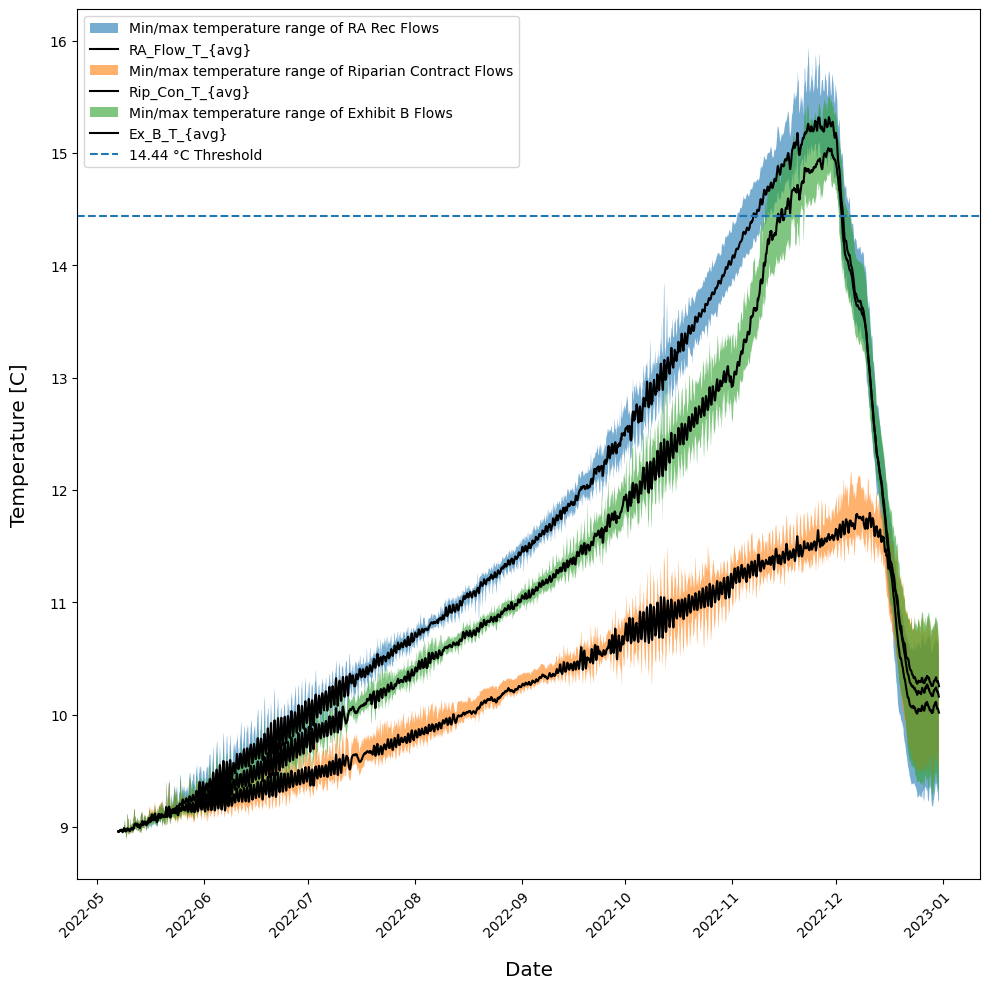

In [8]:

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
_fig, _ax, RA_region, RA_line = mrr_RA.plot_two_structure_composite(4, ax=ax);
_fig, _ax, Rip_Con_region, Rip_Con_line = mrr_RipCon.plot_two_structure_composite(4, ax=ax);
_fig, _ax, ExB_region, ExB_line = mrr_ExB.plot_two_structure_composite(4, ax=ax);

# Modify the labels for the min/max region and average temperature line.
RA_region.set_label("Min/max temperature range of RA Rec Flows")
RA_line.set_label(r"RA_Flow_T_{avg}")

Rip_Con_region.set_label("Min/max temperature range of Riparian Contract Flows")
Rip_Con_line.set_label(r"Rip_Con_T_{avg}")

ExB_region.set_label("Min/max temperature range of Exhibit B Flows")
ExB_line.set_label(r"Ex_B_T_{avg}")

# Draw the 14.44°C threshold line
mrr_RA.plot_threshold_line_y(ax, linestyle="--", label="14.44 °C Threshold")

# Rotate the x-labels to make it so they don't overlap
xticks, labels = ax.get_xticks(), ax.get_xticklabels()
ax.set_xticks(xticks, labels=labels)
ax.set_xticks(xticks, labels=labels, rotation=45, ha="right", rotation_mode="anchor")

# Resize the axis labels
ax.set_ylabel(ax.get_ylabel(), fontsize="x-large", labelpad=15)
ax.set_xlabel(ax.get_xlabel(), fontsize="x-large", labelpad=15)

# Add a legend to the plot
ax.legend(loc="best")

# Resize the figure to accommodate the changes to axis labels
plt.tight_layout()
fig.savefig("2026_ra_flow_comparison.svg")
plt.show()

## Threshold Summary Table

In [9]:
threshold_temperature = 14.44
structure = 4

exb_summary = mrr_ExB.threshold_summary(structure, threshold=threshold_temperature)
exb_summary["Restoration Flow Scenario"] = "ExB"

ra_summary = mrr_RA.threshold_summary(structure, threshold=threshold_temperature)
ra_summary["Restoration Flow Scenario"] = "RA"

ripcon_summary = mrr_RipCon.threshold_summary(structure, threshold=threshold_temperature)
ripcon_summary["Restoration Flow Scenario"] = "RipCon"

df = pd.concat([exb_summary, ra_summary, ripcon_summary])
df

,Tavg [C],Tmin [C],Tmax [C],Days above threshold,Restoration Flow Scenario
2022_Observed_Flow_met2014,11.275752,8.95,15.18,18.752,ExB
2022_Observed_Flow_met2015,11.116259,8.95,14.84,12.041,ExB
2022_Observed_Flow_met2016,11.238634,8.94,15.15,18.744,ExB
2022_Observed_Flow_met2017,11.214058,8.94,15.11,17.079,ExB
2022_Observed_Flow_met2018,11.196420,8.95,15.11,16.082,ExB
2022_Observed_Flow_met2019,11.188354,8.93,14.91,12.039,ExB
2022_Observed_Flow_met2020,11.154814,8.94,14.87,14.082,ExB
2022_Observed_Flow_met2021,11.382926,8.94,15.51,24.621,ExB
2022_Observed_Flow_met2022,11.264985,8.89,15.12,21.125,ExB
2022_Observed_Flow_met2023,11.208032,8.94,15.08,17.908,ExB
